In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
%matplotlib inline
sns.set_style("whitegrid")

In [6]:
df = pd.read_csv('S02-hw-dataset.csv')

In [7]:
df.head()

,user_id,age,country,purchases,revenue
0,1,25.0,FR,7,749
1,2,24.0,RU,5,1115
2,3,52.0,FR,7,399
3,4,31.0,RU,6,654
4,5,NaN,DE,6,1296


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41 entries, 0 to 40
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   user_id    41 non-null     int64  
 1   age        39 non-null     float64
 2   country    41 non-null     object 
 3   purchases  41 non-null     int64  
 4   revenue    41 non-null     int64  
dtypes: float64(1), int64(3), object(1)
memory usage: 1.7+ KB


In [10]:
df.describe()

,user_id,age,purchases,revenue
count,41.000000,39.000000,41.000000,41.000000
mean,20.243902,36.512821,4.829268,820.048780
std,11.659289,18.304259,2.710189,613.127269
min,1.000000,5.000000,-1.000000,0.000000
25%,10.000000,24.000000,3.000000,432.000000
50%,20.000000,33.000000,5.000000,693.000000
75%,30.000000,45.500000,7.000000,1115.000000
max,40.000000,120.000000,11.000000,2475.000000


In [12]:
print("ДОЛЯ ПРОПУСКОВ")
df.isna().mean()

ДОЛЯ ПРОПУСКОВ


,0
user_id,0.00000
age,0.04878
country,0.00000
purchases,0.00000
revenue,0.00000


In [31]:
print("ДУБЛИРУЮЩИЕ СТРОЧКИ")
df.duplicated()

ДУБЛИРУЮЩИЕ СТРОЧКИ


,0
0,False
1,False
2,False
3,False
4,False
5,False
6,False
7,False
8,False
9,False


In [33]:
print("ПОДОЗРИТЕЛЬНЫЙ ВОЗРАСТ (Age > 100 или < 0) ")
age = df[(df['age'] < 0) | (df['age'] > 100)] # Проверка возраста
display(age)


ПОДОЗРИТЕЛЬНЫЙ ВОЗРАСТ (Age > 100 или < 0) 


,user_id,age,country,purchases,revenue
5,6,120.0,FR,-1,785


In [34]:
print("СТРОКИ С ПРОПУЩЕННЫМ ВОЗРАСТОМ (NaN)")
age = df[df['age'].isna()]
display(age)

СТРОКИ С ПРОПУЩЕННЫМ ВОЗРАСТОМ (NaN)


,user_id,age,country,purchases,revenue
4,5,NaN,DE,6,1296
12,13,NaN,US,9,630


In [27]:
print("НУЛЕВОЙ ДОХОД ПРИ НЕНУЛЕВЫХ КОЛИЧЕСТВАХ")
zero_revenue = df[(df['purchases'] > 0) & (df['revenue'] == 0)]
display(zero_revenue)

НУЛЕВОЙ ДОХОД ПРИ НЕНУЛЕВЫХ КОЛИЧЕСТВАХ


,user_id,age,country,purchases,revenue
10,11,24.0,US,4,0


In [28]:
print("НЕРЕАЛИСТИЧНЫЙ ВОЗРАСТ") #Возраст меньше 10 лет, но покупки есть
age = df[(df['age'] < 10) & (df['purchases'] > 0)]
display(age)

НЕРЕАЛИСТИЧНЫЙ ВОЗРАСТ


,user_id,age,country,purchases,revenue
20,21,5.0,RU,8,1488


In [32]:
print("ПРОВЕРКА НА ОТРИЦАТЕЛЬНЫЕ ПОКУПКИ")
neg_purchases = df[df['purchases'] < 0]
display(neg_purchases)


ПРОВЕРКА НА ОТРИЦАТЕЛЬНЫЕ ПОКУПКИ


,user_id,age,country,purchases,revenue
5,6,120.0,FR,-1,785


В ходе анализа качества данных были обнаружены следующие проблемы: в столбце age обнаружены пропущенные значения (NaN). Это касается пользователей с ID 5 и ID 13. Также был найден один полный дубликат строки (пользователь с ID 10 встречается в датасете дважды с абсолютно идентичными данными). Выявлены аномалии возраста у пользователей с ID 6 (120 лет) и ID 21 (5 лет), отрицательные покупки у ID 6, а также логическое противоречие (нулевая выручка при наличии заказов) у пользователя с ID 11.



In [35]:
df['country'].value_counts() # считаем сколько пользователей в каждой стране

,count
country,
RU,13
FR,12
US,8
DE,6
CN,2


In [37]:
stats = df.groupby('country').agg({  # группируем по странам
    'age': 'mean',  # Средний возраст
    'purchases': 'sum',  # общее количество покупок
    'revenue': 'sum'  # общее количество дохода
})
print(stats)

               age  purchases  revenue
country                               
CN       24.000000          9     2108
DE       34.600000         39     8673
FR       46.250000         51     8111
RU       30.076923         62    10271
US       36.714286         37     4459


In [40]:
mean_age = df['age'].mean()
stats = df.groupby(df['age'] < mean_age).agg({  # группировка по среднему возрасту
    'user_id': 'count',
    'age': 'mean',
    'revenue': 'sum'})
print(stats)

       user_id        age  revenue
age                               
False       17  52.600000    12441
True        24  26.458333    21181


Россия (13 пользователей, 62 покупки, 10 271 доход) является ключевым рынком, лидируя по всем ключевым показателям. Франция выделяется самым высоким средним возрастом (46,25 лет), однако основную выручку генерирует более молодая и многочисленная группа пользователей младше 37,5 лет (24 человека, средний возраст 26,5 лет, 21 181 доход), которая показывает почти вдвое более высокую совокупную доходность по сравнению со старшей группой.


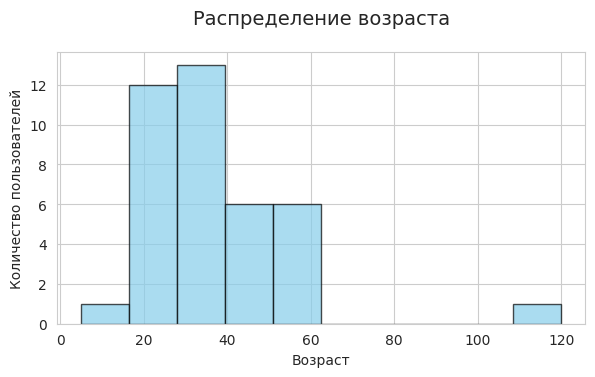

In [42]:
age = df['age'].dropna()
gridsize = (3, 2) # Создание графиков
plt.figure(figsize=(15, 12))

ax = plt.subplot2grid(gridsize, (0, 0))# Сетка
ax.hist(age, bins=10, color='skyblue', edgecolor='black', alpha=0.7)

ax.set_xlabel('Возраст') # Подписи осей и заголовок
ax.set_ylabel('Количество пользователей')
ax.set_title('Распределение возраста', fontsize=14, pad=20)

plt.savefig('hist.png', dpi=300, bbox_inches='tight')
plt.show()

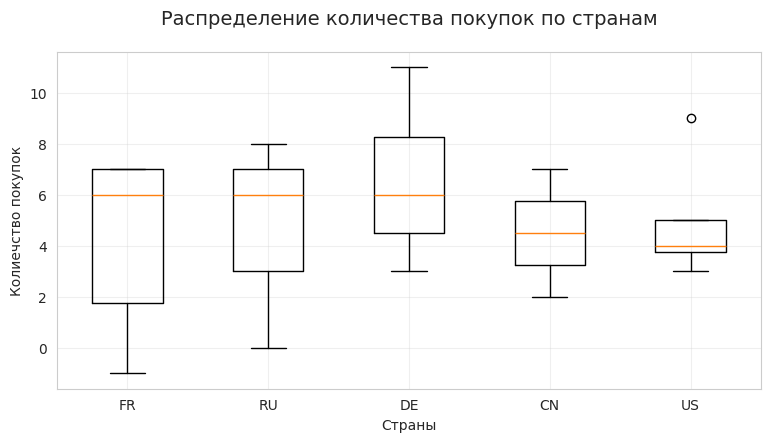

In [44]:
countries = df['country'].unique() # Группируем данные по странам
purchases_by_country = [df[df['country'] == country]['purchases'] for country in countries]

gridsize = (3, 2) # Создание графиков
plt.figure(figsize=(15, 12))
ax = plt.subplot2grid(gridsize, (0, 0)) # Сетка
ax.boxplot(purchases_by_country, tick_labels=countries)

ax.set_xlabel('Страны') # Подписи
ax.set_ylabel('Колиечство покупок')
ax.set_title('Распределение количества покупок по странам', fontsize=14, pad=20)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('boxplot.png', dpi=300, bbox_inches='tight')
plt.show()


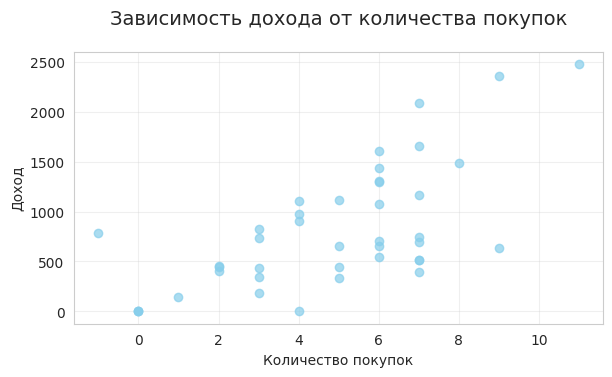

In [47]:

gridsize = (3, 2) # Создание графиков
plt.figure(figsize=(15, 12))

ax = plt.subplot2grid(gridsize, (0, 0)) # Сетка
ax.scatter(df['purchases'], df['revenue'], alpha=0.7, color='skyblue')

ax.set_xlabel('Количество покупок')
ax.set_ylabel('Доход')
ax.set_title('Зависимость дохода от количества покупок', fontsize=14, pad=20)

ax.grid(True, alpha=0.3)

plt.savefig('scatter.png', dpi=300, bbox_inches='tight')
plt.show()